# 02 - Exploratory Data Analysis

**Owners: Pornraksa Suksawaeng**

This notebook answers 12 business questions using varied visualizations. Each chart is followed by a written analysis.

**Questions covered:**

| N | Question | Chart type | Owner |
|---|---|---|---|
| 1 | Which products are the bestsellers? | Horizontal bar | Pornraksa |
| 2 | When do customers order? (day + hour) | Heatmap | Pornraksa |
| 3 | Can we predict if a product will be reordered? | → see 03_models | Léo + Mathis |
| 4 | What are the main customer profiles? | → see 04_bonus | Nicolas |
| 5 | Which products are frequently bought together? | → see 04_bonus | Nicolas |
| 6 | Which department has the highest reorder rate? | Bar chart | Pornraksa |
| 7 | Link between days since last order and reorder rate? | Scatter plot | Pornraksa |
| 8 | What proportion of products is organic per department? | Stacked bar | Pornraksa |
| 9 | Which item do customers add to cart first? | Frequency table | Pornraksa |
| 10 | Can we predict the next cart size? | → see 03_models | Léo + Mathis |
| 11 | What is the reorder rate by hour of day? | Line chart | Pornraksa |
| 12 | Which features influence reorder prediction most? | → see 04_bonus SHAP | Nicolas |

## 0. Imports and Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, '..', 'data')

df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))
print(f'Dataset loaded with shape: {df.shape}')
df.head()

Dataset loaded with shape: (13690540, 15)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.0,0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.0,0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.0,0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.0,0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.0,0


### Base dataframes

We define two dataframes here and reuse them throughout the notebook.


In [2]:
df_all = df.copy()

# Exclude first orders, used for any reorder rate analysis
df_reorders = df[df['is_first_order'] == 0].copy()

print(f'df_all shape: {df_all.shape}')
print(f'df_reorders shape: {df_reorders.shape}')
print(f'First orders excluded: {df_all.shape[0] - df_reorders.shape[0]} rows removed')


df_all shape: (13690540, 15)
df_reorders shape: (12811680, 15)
First orders excluded: 878860 rows removed


## Q1 - Which products are the bestsellers?

**Chart: Horizontal bar chart**

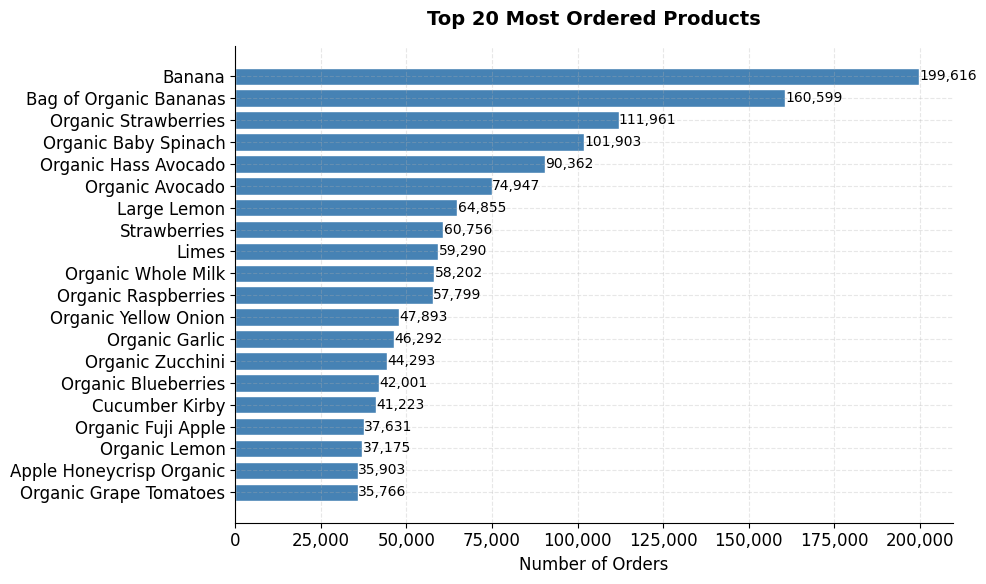

In [3]:
top_n = 20

top_products = (df_all
    .groupby('product_name')['order_id']
    .count()
    .nlargest(top_n)
    .reset_index()
    .rename(columns={'order_id': 'count'})
    .sort_values('count')
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_products['product_name'], top_products['count'], color='steelblue', edgecolor='white')

ax.set_xlabel('Number of Orders')
ax.set_title(f'Top {top_n} Most Ordered Products', pad=15)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2, f'{int(bar.get_width()):,}', va='center', fontsize=10)   

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'q1_bestsellers.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:**
- Need to note the #1 best selling product and how far ahead ?
- Need to note the pattern in the top product (fresh, organic or staples) ?
- Need to note the business action that a sales manager could take from this insight